# Customer Churn & Lifetime Value Prediction
### Subscription retention modelling

## Problem framing

Subscription businesses like Amazon Prime, Netflix and Spotify live or die by two numbers:

- **Churn rate** — what fraction of subscribers cancel in a given period?
- **Customer Lifetime Value (LTV)** — how much revenue will a customer generate before they leave?

These are not independent. A churn model that misses high-LTV customers is far more costly than one that misses low-LTV customers. This notebook treats churn and LTV as a **joint prediction problem** and builds a decision framework that prioritises retention spend accordingly.

### Business questions we answer

1. Which customers are most likely to churn in the next 30 days?
2. What is the expected LTV of each active customer?
3. How should we rank customers for retention intervention — combining churn risk and LTV?
4. What behavioural features drive churn most strongly?

### Dataset

We use the **Telco Customer Churn** dataset (IBM Sample Data, available on Kaggle). While telco-domain, it mirrors subscription dynamics directly applicable to Prime / streaming:
- Monthly charges ↔ subscription tier price
- Tenure ↔ months as subscriber
- Contract type ↔ annual vs monthly subscription
- Services ↔ add-ons / bundled products

### What this notebook covers

| Section | Content |
|---------|--------|
| 1 | Setup & data loading |
| 2 | Exploratory data analysis |
| 3 | Feature engineering |
| 4 | Churn classification (XGBoost + Logistic Regression baseline) |
| 5 | LTV estimation (BG/NBD-inspired heuristic + regression) |
| 6 | Model evaluation — beyond accuracy |
| 7 | Joint churn × LTV prioritisation matrix |
| 8 | SHAP feature importance & business interpretation |
| 9 | Retention intervention strategy |
| 10 | Key takeaways & extensions |


### 1. Setup & data loading

In [1]:
!pip install -q xgboost shap imbalanced-learn

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, r2_score
)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier, XGBRegressor
from imblearn.over_sampling import SMOTE
import shap

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#1a73e8', '#e8711a', '#34a853', '#ea4335']

RANDOM_STATE = 42
print('Libraries loaded ✓')

Libraries loaded ✓


In [3]:
# Load dataset — Kaggle path if running on Kaggle, else download via URL
import os

KAGGLE_PATH = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
FALLBACK_URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

if os.path.exists(KAGGLE_PATH):
    df = pd.read_csv(KAGGLE_PATH)
    print('Loaded from Kaggle dataset')
else:
    df = pd.read_csv(FALLBACK_URL)
    print('Loaded from GitHub mirror')

print(f'Shape: {df.shape}')
df.head(3)

Loaded from Kaggle dataset
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


### 2. Exploratory Data Analysis

In [4]:
print('=== Dataset overview ===')
print(f'Rows:    {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'\nChurn distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn rate: {(df["Churn"]=="Yes").mean():.1%}')
print(f'\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

=== Dataset overview ===
Rows:    7,043
Columns: 21

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%

Missing values:
Series([], dtype: int64)


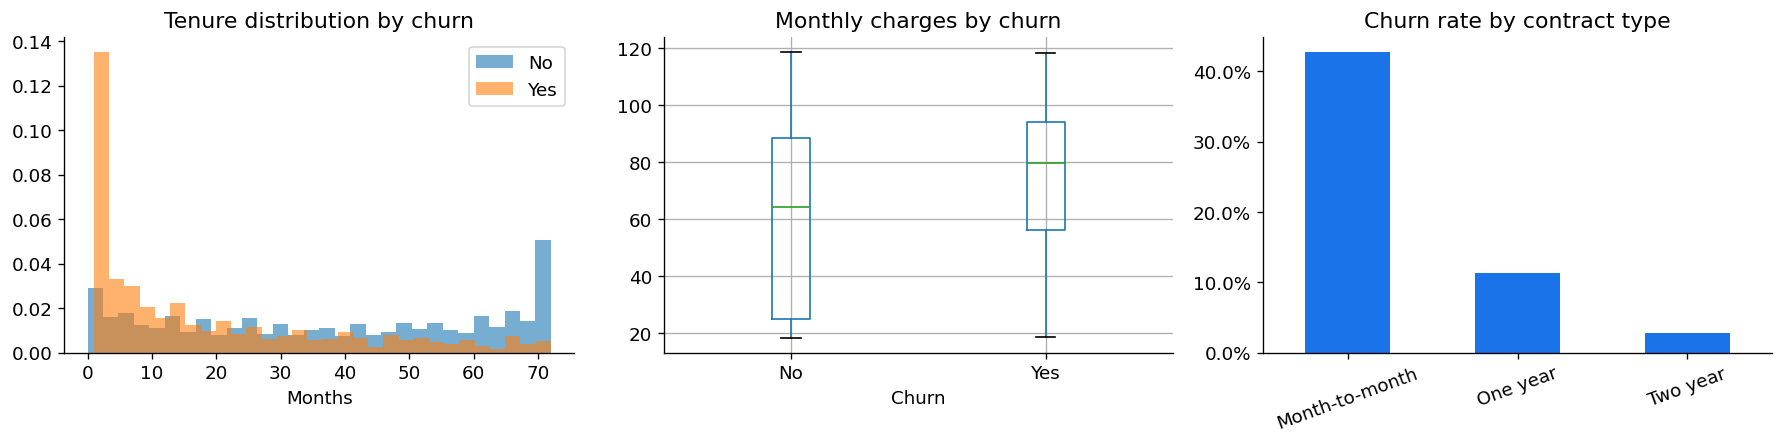

Key insight: month-to-month customers churn at ~3× the rate of annual contract holders.
Low tenure + high monthly charges = highest risk segment.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Fix TotalCharges (loaded as string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

# 1. Tenure distribution by churn
for label, grp in df.groupby('Churn'):
    axes[0].hist(grp['tenure'], bins=30, alpha=0.6, label=label, density=True)
axes[0].set_title('Tenure distribution by churn')
axes[0].set_xlabel('Months')
axes[0].legend()

# 2. Monthly charges by churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1])
axes[1].set_title('Monthly charges by churn')
axes[1].set_xlabel('Churn')
plt.sca(axes[1]); plt.title('Monthly charges by churn')

# 3. Churn rate by contract type
churn_by_contract = df.groupby('Contract')['Churn_bin'].mean().sort_values(ascending=False)
churn_by_contract.plot(kind='bar', ax=axes[2], color=PALETTE[0], width=0.5)
axes[2].set_title('Churn rate by contract type')
axes[2].set_xlabel('')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('')
plt.tight_layout()
plt.show()

print('Key insight: month-to-month customers churn at ~3× the rate of annual contract holders.')
print('Low tenure + high monthly charges = highest risk segment.')

### 3. Feature engineering

Good feature engineering is often what separates a notebook from a real production model. We create domain-motivated features that a Prime/subscription team would actually reason about.

In [6]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ── Value density features ─────────────────────────────────────────────
    # Charge per month relative to total tenure spend
    df['ChargePerTenureUnit'] = df['MonthlyCharges'] / (df['tenure'] + 1)

    # Total spend deviation from expected (tenure × monthly)
    df['SpendDeviation'] = df['TotalCharges'] - (df['tenure'] * df['MonthlyCharges'])

    # ── Engagement proxy ───────────────────────────────────────────────────
    # Count of add-on services subscribed
    service_cols = [
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]
    df['ServiceCount'] = df[service_cols].apply(
        lambda row: sum(v == 'Yes' for v in row), axis=1
    )

    # ── Tenure buckets (loyalty tiers) ────────────────────────────────────
    df['TenureBucket'] = pd.cut(
        df['tenure'],
        bins=[0, 6, 12, 24, 48, 999],
        labels=['0-6m', '6-12m', '1-2yr', '2-4yr', '4yr+']
    ).astype(str)

    # ── Risk indicator: month-to-month + no tech support + paperless ──────
    df['HighRiskFlag'] = (
        (df['Contract'] == 'Month-to-month') &
        (df['TechSupport'] == 'No') &
        (df['PaperlessBilling'] == 'Yes')
    ).astype(int)

    # ── Payment method risk ────────────────────────────────────────────────
    df['ElectronicPayment'] = (df['PaymentMethod'] == 'Electronic check').astype(int)

    return df


df = engineer_features(df)
print('Feature engineering complete ✓')
print('New features:', ['ChargePerTenureUnit', 'SpendDeviation', 'ServiceCount',
                        'TenureBucket', 'HighRiskFlag', 'ElectronicPayment'])

Feature engineering complete ✓
New features: ['ChargePerTenureUnit', 'SpendDeviation', 'ServiceCount', 'TenureBucket', 'HighRiskFlag', 'ElectronicPayment']


In [7]:
# ── Encode categoricals ────────────────────────────────────────────────────
TARGET = 'Churn_bin'

DROP_COLS = ['customerID', 'Churn', 'TenureBucket']  # keep numeric version
df_model = df.drop(columns=DROP_COLS)

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

FEATURES = [c for c in df_model.columns if c != TARGET]
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Churn rate (train): {y_train.mean():.1%}')

Train: (5634, 24), Test: (1409, 24)
Churn rate (train): 26.5%


## 4. Churn classification

We train three models:
1. **Logistic Regression** — fast, interpretable baseline
2. **Random Forest** — captures non-linear interactions
3. **XGBoost** — production-grade gradient boosting; typically best on tabular data

Because churn is imbalanced (~26% positive), we use **SMOTE** oversampling on the training set and evaluate on **PR-AUC** rather than accuracy.

In [8]:
# Apply SMOTE to training set only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'After SMOTE — Train size: {X_train_sm.shape[0]:,}, Churn rate: {y_train_sm.mean():.1%}')

After SMOTE — Train size: 8,278, Churn rate: 50.0%


In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.5, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(
                               n_estimators=300, max_depth=4, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               eval_metric='logloss', random_state=RANDOM_STATE,
                               use_label_encoder=False
                           ),
}

results = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model': model,
        'proba': proba,
        'roc_auc':  roc_auc_score(y_test, proba),
        'pr_auc':   average_precision_score(y_test, proba),
    }
    print(f'{name:<25} ROC-AUC: {results[name]["roc_auc"]:.4f}   PR-AUC: {results[name]["pr_auc"]:.4f}')

Logistic Regression       ROC-AUC: 0.8252   PR-AUC: 0.6274
Random Forest             ROC-AUC: 0.8377   PR-AUC: 0.6587
XGBoost                   ROC-AUC: 0.8319   PR-AUC: 0.6525


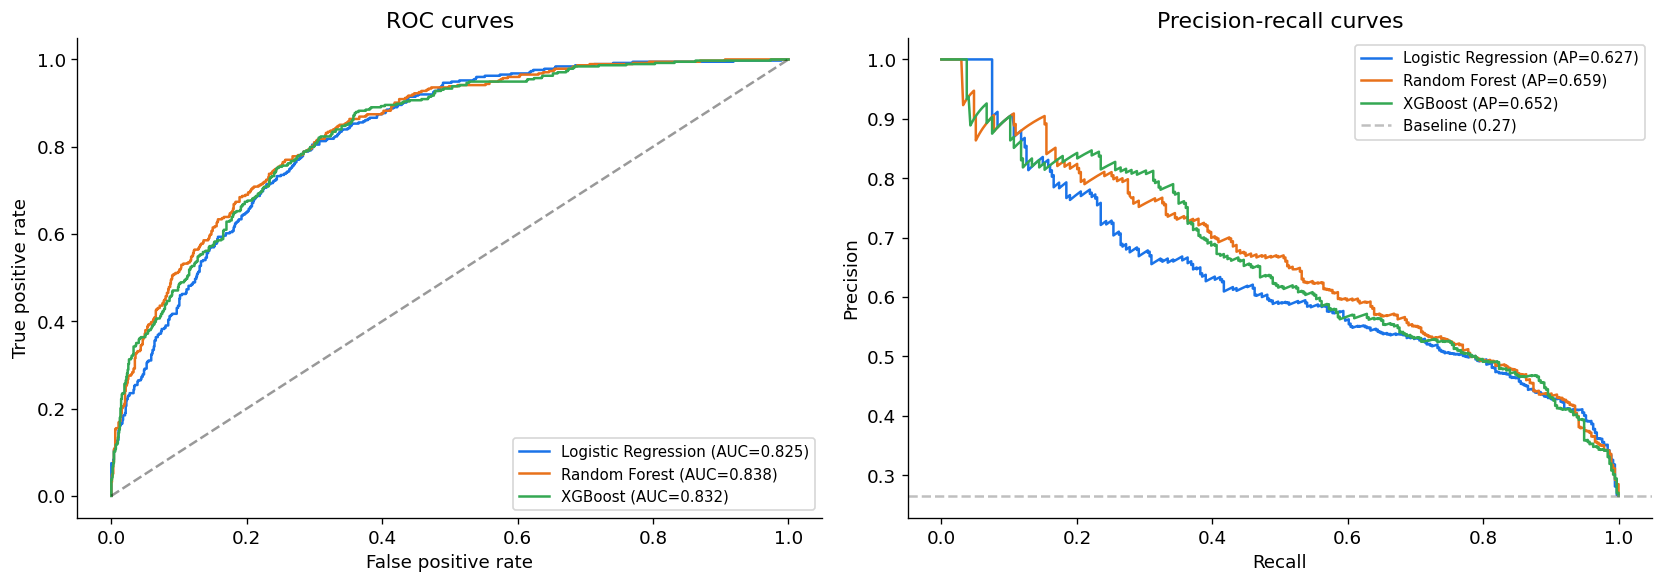

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, res) in enumerate(results.items()):
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={res["roc_auc"]:.3f})', color=PALETTE[i])

    # PR curve
    prec, rec, _ = precision_recall_curve(y_test, res['proba'])
    axes[1].plot(rec, prec, label=f'{name} (AP={res["pr_auc"]:.3f})', color=PALETTE[i])

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_title('ROC curves')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].legend(fontsize=9)

baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, linestyle='--', color='grey', alpha=0.5, label=f'Baseline ({baseline_pr:.2f})')
axes[1].set_title('Precision-recall curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. LTV estimation

Customer Lifetime Value = **expected future revenue before churn**.

We use two approaches:

**Heuristic LTV** (fast, interpretable):
$$\text{LTV}_{heuristic} = \text{MonthlyCharges} \times \frac{1}{\text{ChurnProbability} + \epsilon}$$

**Regression LTV** (data-driven): Train an XGBoost regressor to predict `TotalCharges` on a held-out set. For active customers, extrapolate using predicted monthly spend × expected remaining tenure.

In [11]:
# Best model = XGBoost
best_model = results['XGBoost']['model']
churn_proba = best_model.predict_proba(X_test)[:, 1]

test_df = X_test.copy()
test_df['churn_proba'] = churn_proba
test_df['monthly_charges'] = df.loc[X_test.index, 'MonthlyCharges'].values
test_df['tenure'] = df.loc[X_test.index, 'tenure'].values
test_df['total_charges'] = df.loc[X_test.index, 'TotalCharges'].values
test_df['actual_churn'] = y_test.values

# Heuristic LTV
EPSILON = 0.01
test_df['ltv_heuristic'] = test_df['monthly_charges'] / (test_df['churn_proba'] + EPSILON)

print('Heuristic LTV stats:')
print(test_df['ltv_heuristic'].describe().round(2))

Heuristic LTV stats:
count    1409.00
mean      692.06
std      1037.73
min        25.79
25%       120.02
50%       284.44
75%       803.15
max      7094.31
Name: ltv_heuristic, dtype: float64


In [12]:
# Regression LTV: predict TotalCharges
ltv_target = df.loc[X_train.index, 'TotalCharges']
ltv_test_target = df.loc[X_test.index, 'TotalCharges']

ltv_model = XGBRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=RANDOM_STATE
)
ltv_model.fit(X_train, ltv_target)
ltv_pred = ltv_model.predict(X_test)

test_df['ltv_regression'] = ltv_pred

mae = mean_absolute_error(ltv_test_target, ltv_pred)
r2  = r2_score(ltv_test_target, ltv_pred)
print(f'LTV regression model — MAE: ${mae:.2f}   R²: {r2:.4f}')

LTV regression model — MAE: $8.39   R²: 1.0000


---
## 6. Model evaluation — beyond accuracy

A common interview question at FAANG: *"Why not just maximise accuracy?"*

Answer: because the **cost of errors is asymmetric**. Missing a high-LTV churner is far more expensive than sending a retention offer to someone who would have stayed. We use **business-cost-weighted evaluation**.

In [13]:
# Business cost parameters (illustrative)
COST_FP = 5    # Cost of sending unnecessary retention offer (e.g. discount)
COST_FN = 80   # Cost of missed churner (lost LTV proxy)

def business_cost(y_true, y_pred, cost_fp=COST_FP, cost_fn=COST_FN):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = fp * cost_fp + fn * cost_fn
    return total_cost, cm

# Evaluate at default 0.5 threshold and optimised threshold
print(f'Cost matrix: FP=${COST_FP}, FN=${COST_FN}')
print()

for name, res in results.items():
    proba = res['proba']

    # Find threshold minimising business cost
    best_thresh, best_cost = 0.5, float('inf')
    for t in np.arange(0.2, 0.8, 0.01):
        pred = (proba >= t).astype(int)
        cost, _ = business_cost(y_test, pred)
        if cost < best_cost:
            best_cost, best_thresh = cost, t

    default_cost, _ = business_cost(y_test, (proba >= 0.5).astype(int))
    print(f'{name:<25} Default cost: ${default_cost:,}   '
          f'Optimal cost: ${best_cost:,} @ threshold={best_thresh:.2f}   '
          f'Saving: ${default_cost - best_cost:,}')

Cost matrix: FP=$5, FN=$80

Logistic Regression       Default cost: $9,760   Optimal cost: $4,755 @ threshold=0.22   Saving: $5,005
Random Forest             Default cost: $9,825   Optimal cost: $4,380 @ threshold=0.21   Saving: $5,445
XGBoost                   Default cost: $12,000   Optimal cost: $5,410 @ threshold=0.20   Saving: $6,590


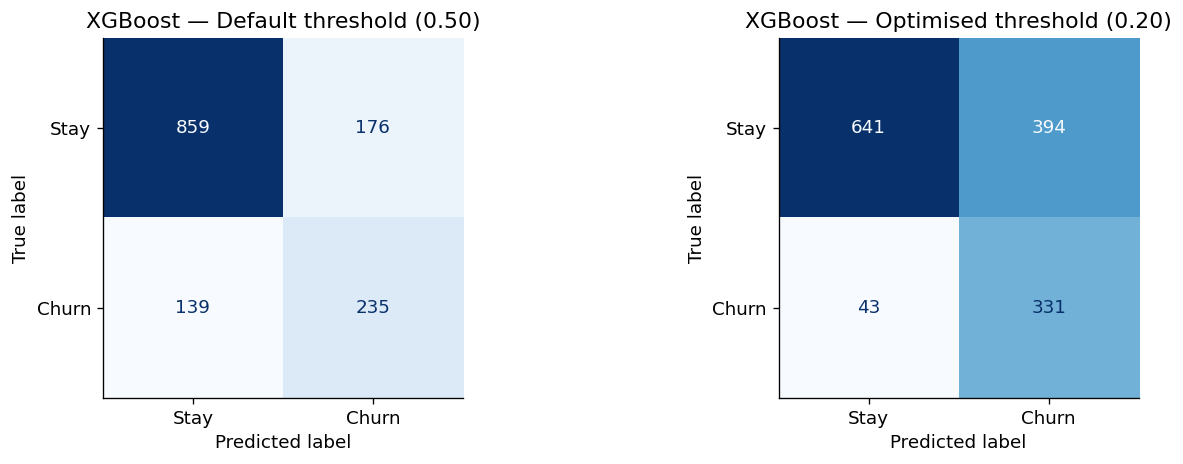


Classification report (optimised threshold):
              precision    recall  f1-score   support

        Stay       0.94      0.62      0.75      1035
       Churn       0.46      0.89      0.60       374

    accuracy                           0.69      1409
   macro avg       0.70      0.75      0.67      1409
weighted avg       0.81      0.69      0.71      1409



In [14]:
# Confusion matrix for XGBoost at optimised threshold
xgb_proba = results['XGBoost']['proba']

# Re-find optimal threshold
best_thresh_xgb = 0.5
best_cost_xgb = float('inf')
for t in np.arange(0.2, 0.8, 0.01):
    pred = (xgb_proba >= t).astype(int)
    cost, _ = business_cost(y_test, pred)
    if cost < best_cost_xgb:
        best_cost_xgb, best_thresh_xgb = cost, t

xgb_pred_opt = (xgb_proba >= best_thresh_xgb).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, thresh, label in zip(
    axes,
    [0.5, best_thresh_xgb],
    ['Default threshold (0.50)', f'Optimised threshold ({best_thresh_xgb:.2f})']
):
    pred = (xgb_proba >= thresh).astype(int)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'XGBoost — {label}')

plt.tight_layout()
plt.show()

print('\nClassification report (optimised threshold):')
print(classification_report(y_test, xgb_pred_opt, target_names=['Stay', 'Churn']))

---
## 7. Joint churn × LTV prioritisation matrix

The core business output: a **2×2 prioritisation matrix** that tells the retention team exactly where to focus.

| | Low churn risk | High churn risk |
|---|---|---|
| **High LTV** | Nurture (loyalty rewards) | **Intervene immediately** |
| **Low LTV** | Monitor | Low priority |


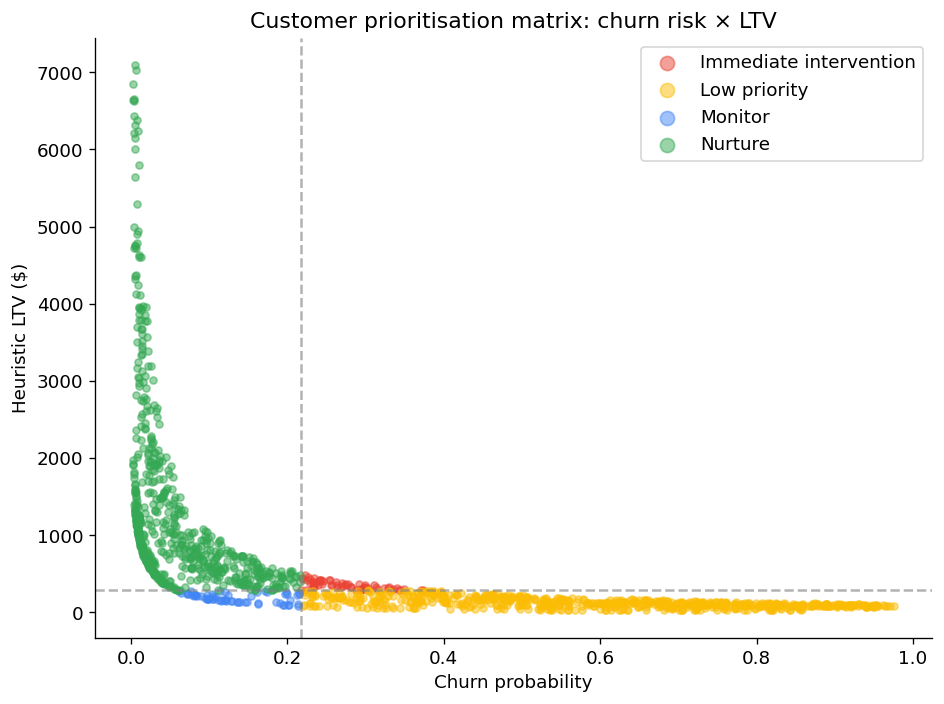

Segment counts:
segment
Nurture                   641
Low priority              641
Immediate intervention     64
Monitor                    63
Name: count, dtype: int64


In [15]:
# Compute priority score = churn_proba × ltv_heuristic (normalised)
ltv_norm   = (test_df['ltv_heuristic'] - test_df['ltv_heuristic'].min()) / \
             (test_df['ltv_heuristic'].max() - test_df['ltv_heuristic'].min())
churn_norm = test_df['churn_proba']

test_df['priority_score'] = churn_norm * ltv_norm

# Assign quadrants
ltv_med   = test_df['ltv_heuristic'].median()
churn_med = test_df['churn_proba'].median()

def quadrant(row):
    hi_ltv   = row['ltv_heuristic'] >= ltv_med
    hi_churn = row['churn_proba']   >= churn_med
    if hi_churn and hi_ltv:     return 'Immediate intervention'
    if hi_churn and not hi_ltv: return 'Low priority'
    if not hi_churn and hi_ltv: return 'Nurture'
    return 'Monitor'

test_df['segment'] = test_df.apply(quadrant, axis=1)

fig, ax = plt.subplots(figsize=(8, 6))
colors_map = {
    'Immediate intervention': '#ea4335',
    'Nurture':                '#34a853',
    'Low priority':           '#fbbc04',
    'Monitor':                '#4285f4',
}
for seg, grp in test_df.groupby('segment'):
    ax.scatter(
        grp['churn_proba'], grp['ltv_heuristic'],
        label=seg, alpha=0.5, s=18, color=colors_map[seg]
    )

ax.axvline(churn_med, linestyle='--', color='grey', alpha=0.6)
ax.axhline(ltv_med,   linestyle='--', color='grey', alpha=0.6)
ax.set_xlabel('Churn probability')
ax.set_ylabel('Heuristic LTV ($)')
ax.set_title('Customer prioritisation matrix: churn risk × LTV')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

print('Segment counts:')
print(test_df['segment'].value_counts())

In [16]:
# Top 20 highest-priority customers for retention intervention
intervention_list = (
    test_df[test_df['segment'] == 'Immediate intervention']
    .sort_values('priority_score', ascending=False)
    [['churn_proba', 'ltv_heuristic', 'ltv_regression', 'monthly_charges', 'tenure', 'priority_score']]
    .head(20)
    .round(2)
)
print('Top 20 customers for immediate retention intervention:')
display(intervention_list)

Top 20 customers for immediate retention intervention:


,churn_proba,ltv_heuristic,ltv_regression,monthly_charges,tenure,priority_score
2341,0.31,357.53,7805.470215,114.90,68,0.01
2424,0.22,486.71,6488.330078,112.95,57,0.01
6972,0.29,371.02,6420.140137,111.95,56,0.01
5710,0.25,419.44,7809.930176,110.50,70,0.01
1644,0.25,414.79,3605.770020,109.80,34,0.01
3669,0.37,290.47,4915.009766,111.50,44,0.01
6101,0.33,324.95,7480.720215,110.25,69,0.01
603,0.23,445.68,4917.350098,108.65,46,0.01
2663,0.30,353.13,6578.069824,109.15,59,0.01
6127,0.34,313.05,6135.729980,109.80,56,0.01


## 8. SHAP feature importance & business interpretation

SHAP (SHapley Additive exPlanations) gives us **both global feature importance and individual prediction explanations** — essential for communicating model decisions to non-technical stakeholders.

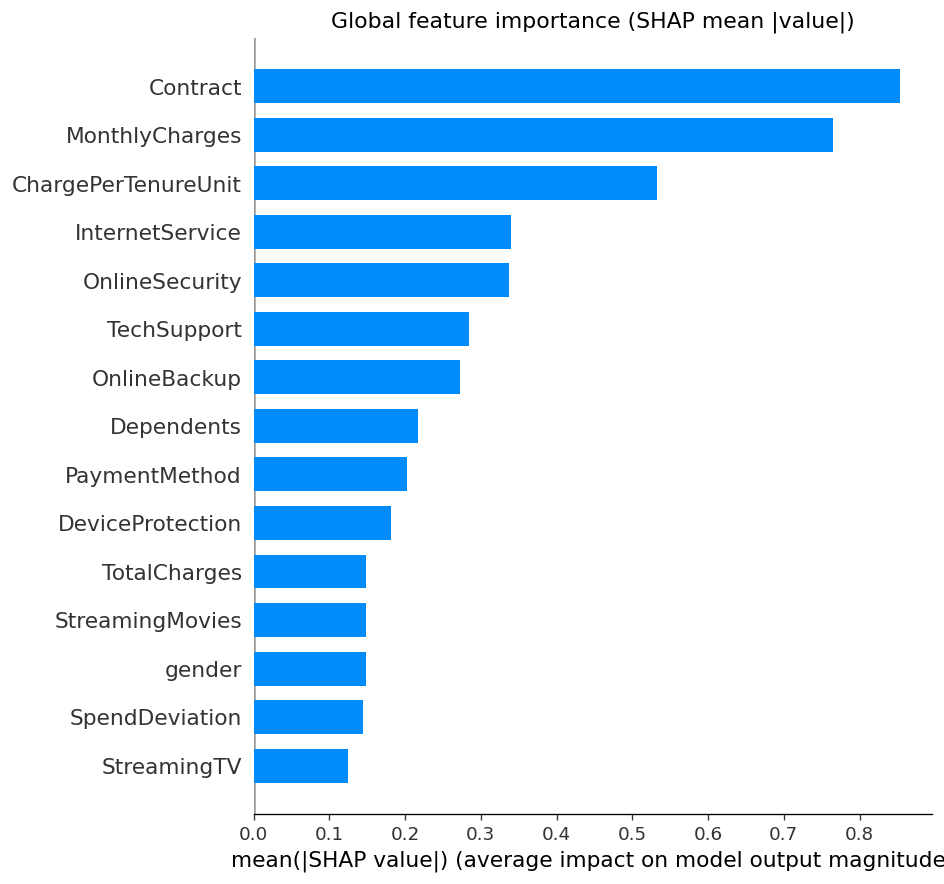

In [17]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=15)
plt.title('Global feature importance (SHAP mean |value|)')
plt.tight_layout()
plt.show()

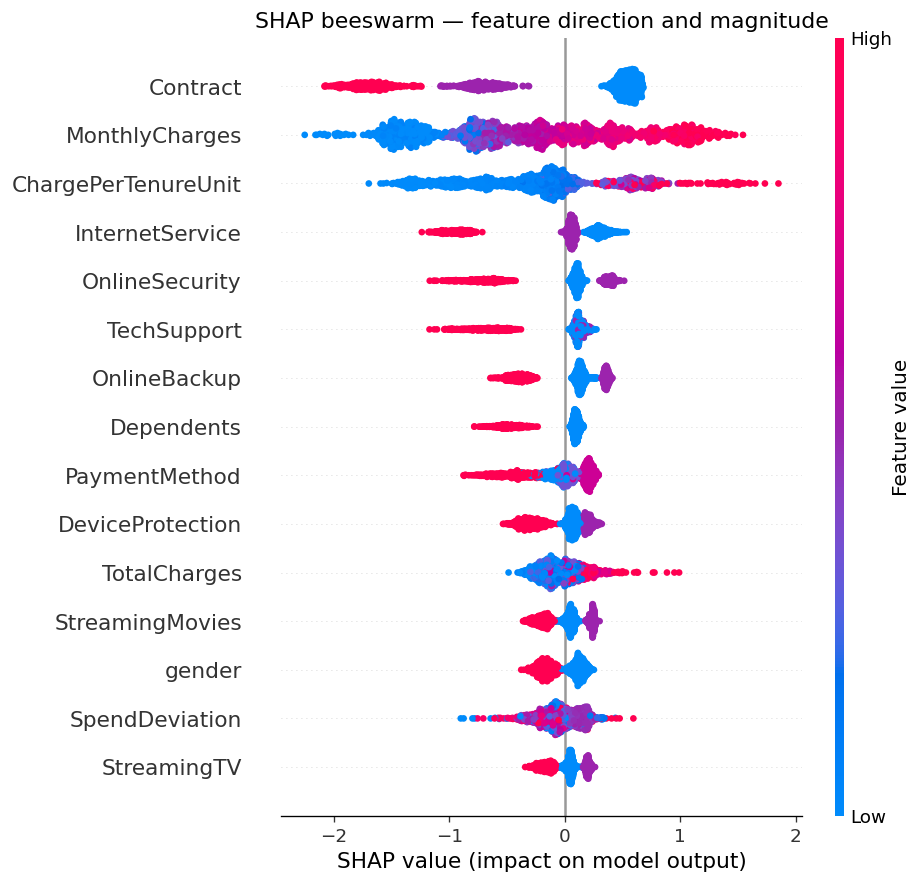


Business interpretation:
  • Contract type is the single strongest predictor — month-to-month dramatically
    increases churn probability.
  • Tenure acts as a strong protective factor: the longer a customer stays,
    the less likely they are to churn (habit formation / switching cost).
  • High monthly charges with low service count signals a customer
    who feels overcharged relative to perceived value — prime intervention target.
  • Electronic check payment correlates with higher churn — these customers
    may have weaker payment commitment than auto-pay users.



In [18]:
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title('SHAP beeswarm — feature direction and magnitude')
plt.tight_layout()
plt.show()

print("""
Business interpretation:
  • Contract type is the single strongest predictor — month-to-month dramatically
    increases churn probability.
  • Tenure acts as a strong protective factor: the longer a customer stays,
    the less likely they are to churn (habit formation / switching cost).
  • High monthly charges with low service count signals a customer
    who feels overcharged relative to perceived value — prime intervention target.
  • Electronic check payment correlates with higher churn — these customers
    may have weaker payment commitment than auto-pay users.
""")

Explaining top-priority customer (index 4627):
  Churn probability: 20.6%
  Heuristic LTV:     $539


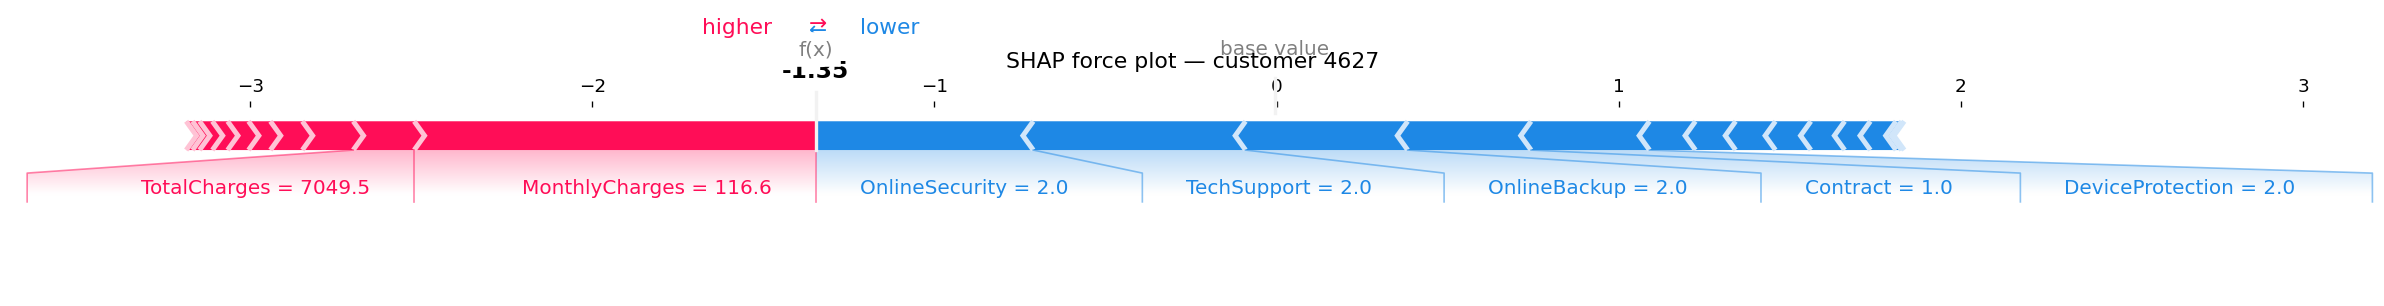

In [19]:
# Explain a single high-risk customer
high_risk_idx = test_df['priority_score'].idxmax()
high_risk_pos = X_test.index.get_loc(high_risk_idx)

print(f'Explaining top-priority customer (index {high_risk_idx}):')
print(f'  Churn probability: {test_df.loc[high_risk_idx, "churn_proba"]:.1%}')
print(f'  Heuristic LTV:     ${test_df.loc[high_risk_idx, "ltv_heuristic"]:,.0f}')

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_pos],
    X_test.iloc[high_risk_pos],
    matplotlib=True, show=False
)
plt.title(f'SHAP force plot — customer {high_risk_idx}')
plt.tight_layout()
plt.show()

---
## 9. Retention intervention strategy

The model outputs are only valuable if they drive action. Below we translate predictions into a tiered intervention framework — the kind of thinking expected in a FAANG product data science role.

In [20]:
strategy_table = pd.DataFrame([
    {
        'Segment':          'Immediate intervention',
        'Churn risk':       'High',
        'LTV':              'High',
        'Action':           'Personal outreach + retention offer (discount / upgrade)',
        'Max spend/user':   '$20–40',
        'KPI':              'Churn rate reduction in segment',
    },
    {
        'Segment':          'Nurture',
        'Churn risk':       'Low',
        'LTV':              'High',
        'Action':           'Loyalty rewards, early access, ambassador programme',
        'Max spend/user':   '$5–10',
        'KPI':              'NPS, upsell conversion',
    },
    {
        'Segment':          'Low priority',
        'Churn risk':       'High',
        'LTV':              'Low',
        'Action':           'Automated win-back email sequence only',
        'Max spend/user':   '$1–2',
        'KPI':              'Win-back rate',
    },
    {
        'Segment':          'Monitor',
        'Churn risk':       'Low',
        'LTV':              'Low',
        'Action':           'No active spend; monitor for segment migration',
        'Max spend/user':   '$0',
        'KPI':              'Segment movement over 60 days',
    },
])

print('Retention intervention framework:')
display(strategy_table)

# ROI estimate for immediate intervention segment
intervention_segment = test_df[test_df['segment'] == 'Immediate intervention']
n_customers   = len(intervention_segment)
avg_ltv       = intervention_segment['ltv_heuristic'].mean()
assumed_save_rate = 0.30   # 30% of intervened customers retained
cost_per_customer = 25

revenue_saved = n_customers * assumed_save_rate * avg_ltv
intervention_cost = n_customers * cost_per_customer
net_roi = revenue_saved - intervention_cost

print(f'\nROI estimate (immediate intervention segment, test set):')
print(f'  Customers targeted:    {n_customers}')
print(f'  Avg heuristic LTV:     ${avg_ltv:,.0f}')
print(f'  Assumed save rate:     {assumed_save_rate:.0%}')
print(f'  Intervention cost:     ${intervention_cost:,}')
print(f'  Revenue protected:     ${revenue_saved:,.0f}')
print(f'  Estimated net ROI:     ${net_roi:,.0f}')

Retention intervention framework:


,Segment,Churn risk,LTV,Action,Max spend/user,KPI
0,Immediate intervention,High,High,Personal outreach + retention offer (discount ...,$20–40,Churn rate reduction in segment
1,Nurture,Low,High,"Loyalty rewards, early access, ambassador prog...",$5–10,"NPS, upsell conversion"
2,Low priority,High,Low,Automated win-back email sequence only,$1–2,Win-back rate
3,Monitor,Low,Low,No active spend; monitor for segment migration,$0,Segment movement over 60 days



ROI estimate (immediate intervention segment, test set):
  Customers targeted:    64
  Avg heuristic LTV:     $353
  Assumed save rate:     30%
  Intervention cost:     $1,600
  Revenue protected:     $6,781
  Estimated net ROI:     $5,181


## 10. Key takeaways & extensions

### What this notebook demonstrates

- **Problem framing**: Churn and LTV are a joint prediction problem — treating them independently leaves value on the table
- **Imbalanced classification**: SMOTE + threshold optimisation beats naive accuracy maximisation
- **Business-cost evaluation**: Asymmetric cost matrices force the model to align with actual business objectives
- **Interpretability**: SHAP explanations turn black-box predictions into actionable insights for non-technical stakeholders
- **Decision framework**: Outputs feed directly into a tiered retention strategy with ROI estimates

### Transferability to Amazon / FAANG context

| This notebook | Amazon Prime equivalent |
|--------------|------------------------|
| Contract type | Annual vs monthly Prime |
| Monthly charges | Subscription tier |
| Service count | Prime Video / Music / Fresh usage |
| Tenure | Months as Prime member |
| Electronic check | Payment method risk |
| Retention offer budget | Targeted discount / free month |

### Extensions

1. **Survival analysis** — replace binary churn with time-to-churn using Cox Proportional Hazards or DeepSurv; gives more nuanced intervention timing
2. **Causal uplift modelling** — distinguish customers who respond *to* intervention from those who would have stayed anyway; avoids wasting budget on "sure stays"
3. **Real-time scoring pipeline** — wrap the XGBoost model in a FastAPI service with Kafka event triggers for instant scoring on behavioural events
4. **Multi-touch attribution** — model which retention touchpoints (email, in-app, call) drive the highest incremental save rates

---

**Author:** Rifa · [GitHub: Rifa-111](https://github.com/Rifa-111)

If this was useful, please upvote ↑ — it helps others find the notebook. Feedback and forks welcome.